<a href="https://colab.research.google.com/github/aidanrem/cs666student/blob/main/CS666_Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

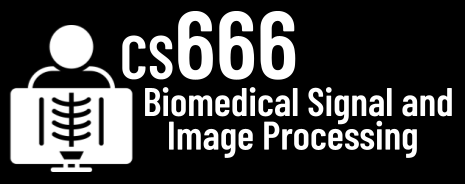
#Assignment 4

In [2]:
# NAME: Aidan Remington

In [3]:
# In this assignment, we will create a Random Forest classifier to detect pneumonia and covid in xrays!

In [4]:
# load numpy and matplotlib
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [5]:
# we are using mahotas again, so lets install it!
!pip install mahotas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 14.0 MB/s eta 0:00:00


In [6]:
# our imports include sklearn this time
import mahotas as mh
import os
from sklearn.ensemble import RandomForestClassifier

**Task 1:** Download, extract, and load the data! [15 Points]

In [14]:
# Please download this file: https://cs666.org/data/xray/ with the wget command!
# Note: Please use the forwarded dropbox link and change dl=0 to dl=1!
# This is a subset of the Kaggle Pneumonia + Covid Datasets!
!wget -O xray.zip "https://www.dropbox.com/scl/fi/sso8jwvfhoxqarp4zd3fb/xray.zip?rlkey=rvjqu3yj6gmw3r7gmst4ke9fl&st=isrganmd&dl=1"

--2026-04-22 02:12:52--  https://www.dropbox.com/scl/fi/sso8jwvfhoxqarp4zd3fb/xray.zip?rlkey=rvjqu3yj6gmw3r7gmst4ke9fl&st=isrganmd&dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.65.18, 2620:100:6022:18::a27d:4212
Connecting to www.dropbox.com (www.dropbox.com)|162.125.65.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc83d7be642378e212660d8283a3.dl.dropboxusercontent.com/cd/0/inline/C_ApZMdCWYztE5ObHnA45WlKHYlGaa_NQq_HzBuGnfHcawqdKGDhcKUHxniw3np5gDNmJtKJsubmIjzMoZuSvwuRa6rbaXfguOWtzKLLrQGbPvR5TEW5dDFjY1X40iIx9ck/file?dl=1# [following]
--2026-04-22 02:12:53--  https://uc83d7be642378e212660d8283a3.dl.dropboxusercontent.com/cd/0/inline/C_ApZMdCWYztE5ObHnA45WlKHYlGaa_NQq_HzBuGnfHcawqdKGDhcKUHxniw3np5gDNmJtKJsubmIjzMoZuSvwuRa6rbaXfguOWtzKLLrQGbPvR5TEW5dDFjY1X40iIx9ck/file?dl=1
Resolving uc83d7be642378e212660d8283a3.dl.dropboxusercontent.com (uc83d7be642378e212660d8283a3.dl.dropboxusercontent.com)... 162.125.65.15, 2620:100:6022:15::a27

In [16]:
# Run this code to extract the zip file and to create
# the folder structure of normal/, pneumonia/, and covid/ images.
# Each folder contains the first images of the Kaggle datasets.
import zipfile
with zipfile.ZipFile('xray.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

NORMAL_DIR = 'normal/'
PNEUMONIA_DIR = 'pneumonia/'
COVID_DIR = 'covid/'

In [17]:
# Here we load the first image from the normal dataset.
img = mh.imread(NORMAL_DIR + 'IM-0115-0001.jpeg')

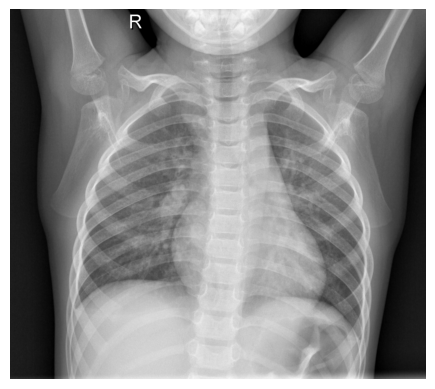

In [18]:
# TODO: Please display this image and print the dimensions!
import matplotlib.pyplot as plt

plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

In [19]:
# TODO: YOUR CODE
print(img.shape)

(1858, 2090)


**Task 2:** Let's do some data wrangling and more visualization! [30 Points]

In [21]:
import numpy as np

folders = [NORMAL_DIR, PNEUMONIA_DIR, COVID_DIR]
data = [[],[],[]]

for f_index,f in enumerate( folders ):
  all_files = os.listdir( f )

  data[f_index] = np.zeros( (len(all_files), 300, 300), dtype=np.float32)

  for i in range(len(all_files)):
    loaded_image = mh.imread( f + '/' + all_files[i] )
    if loaded_image.ndim > 2:
      loaded_image = mh.colors.rgb2gray(loaded_image[:,:,:3])

    loaded_image = mh.imresize( loaded_image, (300, 300) )
    img_shape = loaded_image.shape

    data[f_index][ i, 0:img_shape[0], 0:img_shape[1] ] = loaded_image

In [22]:
# The two code blocks above perform 3 data wrangling operations.
# Which ones?
# Hint: The first two might be more obvious but the third one happens in the
# last line.
# TODO: Operation 1) Read
# TODO: Operation 2) rgb2gray
# TODO: Operation 3) padding

In [ ]:
# Now, let's look at the first 5 normal_images and the first 5 pneumonia_images.
# TODO: Please visualize multiple images at once.
# Hint: You can use one of the following answers from StackOverflow for this:
# https://stackoverflow.com/questions/41210823/using-plt-imshow-to-display-multiple-images

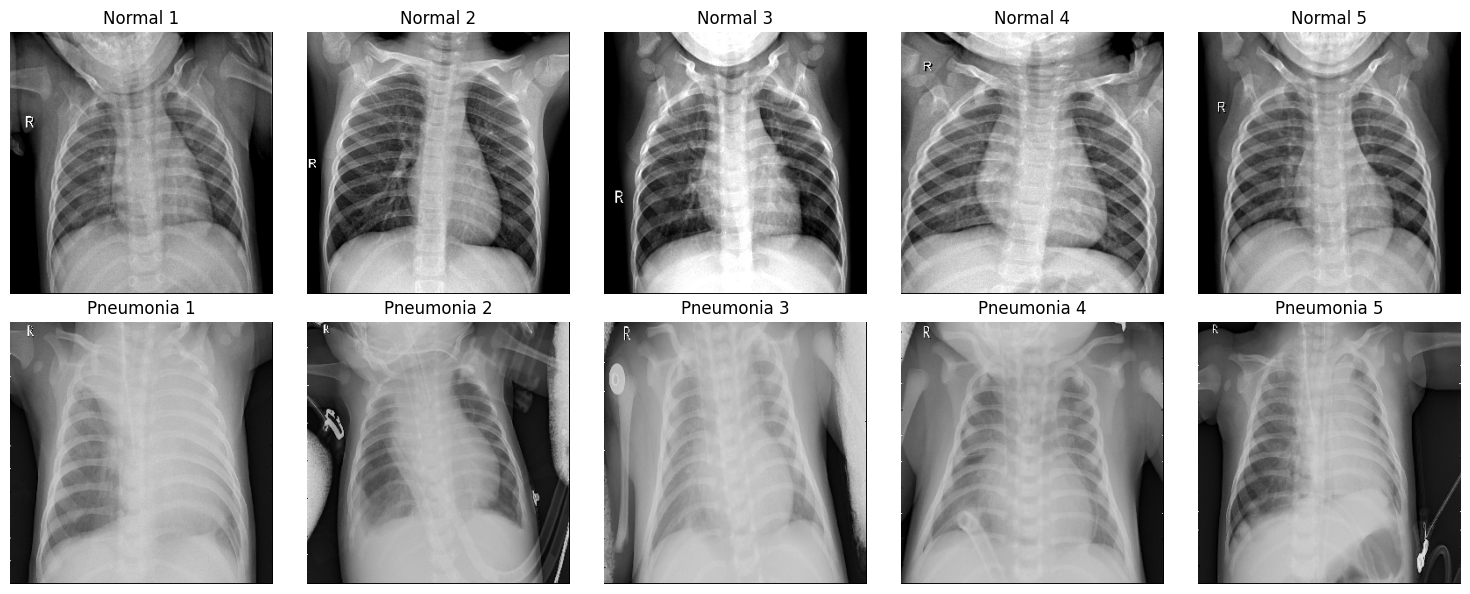

In [23]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i in range(5):
    axes[0, i].imshow(data[0][i], cmap='gray')
    axes[0, i].set_title(f'Normal {i+1}')
    axes[0, i].axis('off')

    axes[1, i].imshow(data[1][i], cmap='gray')
    axes[1, i].set_title(f'Pneumonia {i+1}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

**Task 3:** Setup training and testing data. [15 Points]

In [24]:
# Any supervised machine learning algorithm requires disjunct sets of
# training and testing data.
#
# For each, we will create a balanced dataset that includes an equal number
# of normal xrays, pneumonia xrays, and covid xrays.
#
# The training data X_train will include 180 images (60 normal, 60 pneumonia, 60 covid).
# The testing data X_test will include the remaining 120 images (40 normal, 40 pneumonia, 40 covid).
#
# Supervised learning means that we tell the algorithm which image is normal
# and which image is pneumonia. For this, we need the y_train vector.
# The vector shall be 0 for a normal image, and 1 for a pneumonia, and 2 for a covid scan.

In [28]:
TRAINING_COUNT = 60

X_train = np.zeros( (TRAINING_COUNT * 3, 300*300 ), dtype=np.float32)
t_pos = 0

for d in data:
  for image in d[0:TRAINING_COUNT]:
    image = image.ravel() # flatten the image
    image /= image.max() # normalize the image
    X_train[t_pos] = image
    t_pos += 1

In [29]:
# TODO: Please create the y_train vector with 0 for a normal image,
# 1 for a pneumonia, and 2 for covid. This needs to a numpy array.
y_train = np.array([0]*60 + [1]*60 + [2]*60)

In [30]:
TESTING_COUNT = 40

X_test = np.zeros( (TESTING_COUNT * 3, 300*300 ), dtype=np.float32)
t_pos = 0

for d in data:
  for image in d[TRAINING_COUNT:TRAINING_COUNT+TESTING_COUNT]:
    image = image.ravel() # flatten the image
    image /= image.max() # normalize the image
    X_test[t_pos] = image
    t_pos += 1

In [32]:
# TODO: Please create the y_test vector with 0 for a normal image,
# 1 for a pneumonia, and 2 for covid. This needs to a numpy array.
y_test = np.array([0]*40 + [1]*40 + [2]*40)

**Task 4:** Let's train and evaluate the Random Forest! [30 Points]

In [33]:
# Let's shuffle our training data.
p = np.random.permutation(len(X_train))
X_train = X_train[p]
y_train = y_train[p]

In [34]:
# With scikit-learn, we can easily set up a default Random Forest classifier.
clf = RandomForestClassifier()

In [35]:
# Now, we train the classifier with the training data and the training targets.
# We essentially show the classifier an image and tell whether the image is
# normal or pneumonia or covid.
fitted = clf.fit( X_train, y_train )

In [40]:
# TODO: In just a few sentences, please explain how the Random Forest works.

In [41]:
# TODO: Random forest is made up of individual decision trees that are each
# trained on a different part of the training data and pixels. Trees learn
# rules for classifying their respective parts of the data, and the majority
# vote is taking over all tree outputs to get a final classification.

In [42]:
# After training, we can see how well the classifier predicts our testing data.
# The following command will return the classification accuracy.
clf.score( X_test, y_test )

0.9166666666666666

In [43]:
# TODO: Is the classification accuracy good? And, are you surprised?

In [44]:
# TODO: The accuracy is pretty good, much better than random guessing, which
# would have an accuracy of 33.33% for 3 classes.

**Task 5:** Now, let's decrease the number of trees! [10 Points]

In [45]:
# How many trees are used in Task 4?
print(clf.n_estimators)

100


In [46]:
# TODO: 100

In [47]:
# Now, please use a single tree and observe the testing performance.

In [49]:
from sklearn.tree import DecisionTreeClassifier

clf_single = DecisionTreeClassifier()
clf_single.fit(X_train, y_train)
print(clf_single.score(X_test, y_test))

0.7166666666666667


In [ ]:
# Are you surprised?

In [50]:
# TODO: No, it makes sense that the learning capacity of a single tree is
# smaller than that of a random forest with diverse member trees.

**Bonus:** Let's take a closer look! [33 Points]

In [51]:
# Let's run the fitted classifier on the remaining covid images.
# You might have noticed that there are 199 covid images but we only used 100 so far.
# Please evaluate the classifier on the remaining (previously unseen) 99 covid images
# and check the performance.

In [52]:
# Get the remaining 99 covid images (index 100 onwards)
X_remaining = np.zeros((99, 300*300), dtype=np.float32)
for i, image in enumerate(data[2][100:199]):
    image = image.ravel()
    image /= image.max()
    X_remaining[i] = image

# All are covid, so label = 2
y_remaining = np.array([2]*99)

# Evaluate
print(clf.score(X_remaining, y_remaining))

0.9797979797979798


In [56]:
# Can you figure out which images were misclassified?
# Hint: You can use predictions = clf.predict(X_test_covid_only) for this.
# Can you display them?
# Do you have an idea why these images were problematic?

# They were problematic most likely due to small training data size, and maybe
# because pneumonia and COVID both affect the lungs.

Misclassified indices: [71 84]
They were classified as: [1 0]


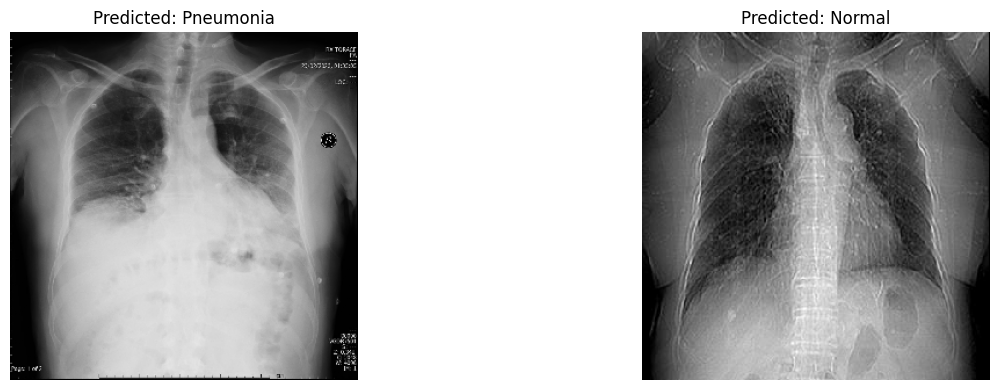

In [57]:
# Get predictions
predictions = clf.predict(X_remaining)

# Find misclassified indices
misclassified = np.where(predictions != 2)[0]
print(f"Misclassified indices: {misclassified}")
print(f"They were classified as: {predictions[misclassified]}")

# Display misclassified images
fig, axes = plt.subplots(1, len(misclassified), figsize=(15, 4))
if len(misclassified) == 1:
    axes = [axes]
for i, idx in enumerate(misclassified):
    axes[i].imshow(data[2][100+idx], cmap='gray')
    axes[i].set_title(f'Predicted: {"Normal" if predictions[idx]==0 else "Pneumonia"}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [58]:
# Great job!!!
#           ___
#       _.-'   \
#      /        \
#     /          \
#    /            `.___
#   ( .--.)\/(,.--.    `-.
#   ,',-. \   / ,-.`.     )
#  ( /   \     /   \ )   / \
#   || .-|     |-. ||---'|  \
#  _|| | |     | | ||_   |   \
# /. \ |_|.---.|_| / ,\  | .^.\
# `.\ `--"     "--' /,'  |/
#   `>  _________ <'
# ,-' ,---.---.---. `-.
# `--'\    \j/    /`--'
#    `.\         /,'
#      \\_______//
#       `-------'       hjw